<a href="https://colab.research.google.com/github/gvp2ms/A01-data-wrangling/blob/main/notebook2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Tiffany Kim

**Date:** 09/02/2026

In [ ]:
# Your Phase 1 solution to the problem goes here.
#Question 1.1
import pandas as pd

airbnb = pd.read_csv('airbnb_hw.csv')

print(airbnb['Price'].dtype)
print(airbnb['Price'].describe())
print()

#Find how many values have commas
comma_total = airbnb['Price'].str.contains(',').sum()
print("There are this many rows with commas:", comma_total)
print("These values (prices that exceed 999) will end up as null values because they contain commas so they aren't registered as valid numbers.")
print()
#Find which rows they're on
with_commas = airbnb[airbnb['Price'].str.contains(',', na=False)]
print(with_commas)
print()

#Replace each value that contains a comma with a commaless one
airbnb['Price_clean'] = pd.to_numeric(airbnb['Price'].str.replace(',', '', regex=False), errors = 'coerce')
#Print information about new "cleaned" Price column
print(airbnb['Price_clean'].dtype)
print(airbnb['Price_clean'].describe())
print()
#Print first three values that had commas to ensure proper removal of comma
print("Example cleaning:")
print(airbnb['Price_clean'].iloc[101])
print(airbnb['Price_clean'].iloc[263])
print(airbnb['Price_clean'].iloc[764])
print()
#Print any missing values in column
print("Missing values after cleaning: ", airbnb['Price_clean'].isna().sum())


object
count     30478
unique      511
top         150
freq       1481
Name: Price, dtype: object

There are this many rows with commas: 181
These values (prices that exceed 999) will end up as null values because they contain commas so they aren't registered as valid numbers.

        Host Id Host Since                                 Name  \
101        8730  2/27/2009                Comfort & Convenience   
263       34915  8/30/2009  Luxurious 2-Floor Manhattan Mansion   
764      112879  4/23/2010  Modern Luxury Meets Old Money Charm   
1272     214148  8/26/2010     LARGE, COMFY 1BDR W/CHARACTER!!!   
1275     213266  8/26/2010   Beautiful 1 Bedroom in Nolita/Soho   
...         ...        ...                                  ...   
28951  37155810  6/30/2015         Central Park Luxury : 115916   
28952  37155810  6/30/2015    Central Park South Place : 112756   
28953  37155810  6/30/2015    Central Park South Views : 112754   
28985  37241813   7/1/2015    VERY Spacious 3BR in 

In [ ]:
#Question 1.2
import pandas as pd

police = pd.read_csv('mn_police_use_of_force.csv')
#Tells how many total rows are in the data
print("There are",len(police), "total rows.")
#Shows the number of rows that have a non-null value for the 'subject_injury' column
print()
print(police['subject_injury'].describe())
print()
#Shows how many nAull values there are for 'subject_injury'
print("The number of rows with null data is:", police['subject_injury'].isnull().sum(),".")
print("The proportion of values that are missing is:", police['subject_injury'].isna().mean(),".")
print("This is a concern because majority of these cases have unknown injury reports, \nmeaning it is hard to confirm how often people were actually injured in police encounters.")
print()

#Replaces all null values in 'subject_injury' with "Unknown" and stores it in a "cleaned" copy
police_clean = police.copy()
police_clean['subject_injury'] = police_clean['subject_injury'].fillna('Unknown')
#Confirms that there are no null values in the cleaned version
print("Number of null values:", police_clean['subject_injury'].isna().sum())
print()

#Cross-tabulation of subject_injury and force_type
print("Yes, there are patterns. Most of the 'unknown' cases happened for bodily force, chemical irritants, and tasers. These are all harder to document injury compared to actual weapons such as firearms and projectiles, making it hard to confirm how many people were actually hurt by the police.")
pd.crosstab(police_clean['subject_injury'], police_clean['force_type'])




There are 12925 total rows.

count     3077
unique       2
top        Yes
freq      1631
Name: subject_injury, dtype: object

The number of rows with null data is: 9848 .
The proportion of values that are missing is: 0.7619342359767892 .
This is a concern because majority of these cases have unknown injury reports, 
meaning it is hard to confirm how often people were actually injured in police encounters.

Number of null values: 0

Yes, there are patterns. Most of the 'unknown' cases happened for bodily force, chemical irritants, and tasers. These are all harder to document injury compared to actual weapons such as firearms and projectiles, making it hard to confirm how many people were actually hurt by the police.


force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal,Less Lethal Projectile,Maximal Restraint Technique,Police K9 Bite,Taser
subject_injury,,,,,,,,,,,
No,0,1093,131,2,33,34,0,1,0,2,150
Unknown,2,7051,1421,0,27,74,87,0,170,31,985
Yes,2,1286,41,0,44,40,0,2,0,44,172


(7117, 23)
Index(['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity',
       'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ',
       'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1',
       'original order', 'Unnamed: 21', 'Unnamed: 22'],
      dtype='object')

(7117, 21)
Index(['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity',
       'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ',
       'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1',
       'original order'],
      dtype='object')


Newest year: 2026.0
Oldest year: 5.0

Most attacks in a year: 143
Year: 2015.0

Least attacks in a year: 16
Year: 1945.0

Average attacks per year: 64.14942528735632

Year_clean
2015.0    143
2017.0    141
2016.0    133
2011.0    128
2014.0    126
         ... 
1977.0     26
1978.0     26
1979.0     25
1940.0     24
1945.0     16
Name: count, Length: 87, dtype: int64
According to the data, at

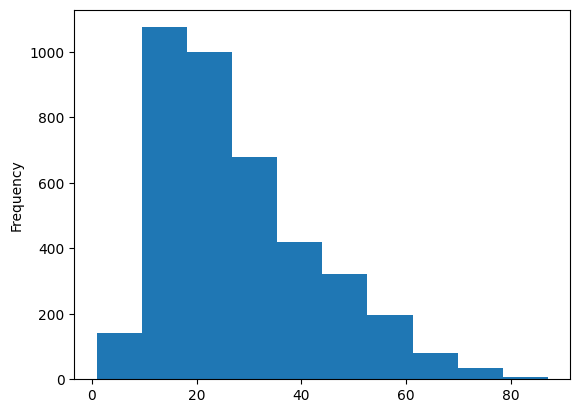

In [ ]:
#Question 2
import pandas as pd
shark = pd.read_excel('GSAF5.xls')
#Number of rows and columns in the data
print(shark.shape)
#Lists out all the columns in the data, including the Unnamed columns
print(shark.columns)
print()

#Makes a copy of the data and removes all columns that have "Unnamed"
shark_clean = shark.copy()
shark_clean = shark_clean.drop(columns=shark_clean.filter(like="Unnamed").columns)
#Reprints the number of rows and columns and column names, confirming "Unnamed" columns were removed
print(shark_clean.shape)
print(shark_clean.columns)
print()

#Removes all null years
shark['Year_clean'] = shark['Year'].replace(0, pd.NA).dropna()
print()

print("Newest year:", shark['Year_clean'].max())
print("Oldest year:", shark['Year_clean'].min())
print()
#Removes all years before 1940
shark_1940 = shark[shark['Year_clean'] >= 1940]
#Counts the number of attacks per year
attacks_by_year = shark_1940.value_counts('Year_clean')
#Prints the maximum number of attacks and which year it occured
print("Most attacks in a year:" ,attacks_by_year.max())
print("Year:", attacks_by_year.idxmax())
print()
#Prints the minimum number of attacks and which year it occured
print("Least attacks in a year:" ,attacks_by_year.min())
print("Year:", attacks_by_year.idxmin())
print()
#Prints the average attacks per year
print("Average attacks per year:" ,attacks_by_year.mean())
print()
print(attacks_by_year)
#attacks_by_year.plot()
print("According to the data, attacks have generally been increasing over time. However, there was a significant drop in attacks since the mid 2010s.")
print()

#Removes all null or "?" ages
shark['Ages_clean'] = shark['Age'].replace('?',pd.NA)
ages = pd.to_numeric(shark['Ages_clean'].dropna(), errors = 'coerce')
#Plots ages as a histogram
ages.plot(kind='hist')
print()

#Number of total reports
print("There were", len(shark), "reports total.")
#Number of reports for "M" sex
gender_male = shark['Sex'].str.contains('M').sum()
print("Of these,", gender_male, "were male.")
#Proportion of "M"/total
print("So, the proportion of victims that are male is:", gender_male/len(shark),".")
print()

#Uses if/else loop to keep the "Provoked" and "Unprovoked" types and keeping all else as "Unknown"
shark['Type_clean'] = shark['Type'].apply(lambda x: x if x in ["Provoked", "Unprovoked"] else "Unknown")
#Finding the proportion of "Unprovoked" attacks
prop_unprovoked = (shark["Type"] == "Unprovoked").mean()
print("The proportion of unknown attacks is:", prop_unprovoked)



## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

\- **Phase 1 commit SHA ID:** 5c8fb5b08c3826f80c2412ca1c354577570336c7
- **AI tool and model used:** Google Gemini 3

### *Prompts used

1.1 [Gave file] Modify my code so that it's simpler and easier to understand. Also, can you write comments to explain the code that is being written.

1.2 This is my code. I'm tasked to clean the subject_injury column, handle the Na's, find the proportion of values missing, and cross tabulate it with the force_type column. Can you make more code more concise and organized. [Gave file]

2. [Given file]

this is my code. for this assignment, we were tasked to remove all columns with no data, clear the year variable and check the ranges and filter it so that only years after 1940 and check trends (increasing decreasing), clean the age variable and make a histogram, find the proportion of male victims, and to clean the type variable so it only takes three values: provoked unprovoked and unknown and find proprotion of unprovoked.



can you clean up my code, make it easier to navigate, and organize



### *AI-proposed changes


#Question 1.1 Suggestions

Here are some concrete ways to refine and improve your Phase 1 pandas solution:

Vectorize comma replacement using .dropna() or direct string casting: Calling .str directly on a column containing NaNs can throw warnings or errors depending on pandas versions. Standardize with airbnb['Price'].astype(str).str.replace(',', '') or handle nulls explicitly upfront.

Streamline comma counting without redundant lookups: Avoid running .str.contains(',') twice. Store the boolean mask (e.g., has_comma = airbnb['Price'].str.contains(',', na=False)) in a variable to print both the total count and the filtered DataFrame efficiently.

Dynamically sample cleaned values: Hardcoding row indices (101, 263, 764) can lead to IndexError if the dataset changes. Use with_commas.index[:3] to dynamically select the first 3 modified rows for verification:

Combine old and new state into a single side-by-side verification: Instead of printing .describe() separately twice, display airbnb[['Price', 'Price_clean']].head() or compare describe() outputs side-by-side for cleaner execution output.

Wrap the data-cleaning logic in a reusable function: Enclose the string-to-numeric pipeline into a function (e.g., clean_price_column(df, col)) to keep Phase 1 modular and easier to unit test or reuse in subsequent assignment phases.

In [2]:
import pandas as pd

# Load dataset
airbnb = pd.read_csv('airbnb_hw.csv')

# --- 1. Initial State Analysis ---
print("=== Initial Column State ===")
print("Data Type:", airbnb['Price'].dtype)
print(airbnb['Price'].describe())
print()

# Identify rows with commas using a single reusable boolean mask
has_comma_mask = airbnb['Price'].astype(str).str.contains(',', na=False)
comma_total = has_comma_mask.sum()

print(f"Rows containing commas (prices > $999): {comma_total}")
print("These values will coerce to NaN during numeric conversion unless commas are removed.")
print()

# Store comma-containing rows for comparison
with_commas = airbnb[has_comma_mask]
print("First 5 rows containing commas:")
print(with_commas[['Price']].head())
print()

# --- 2. Data Cleaning Function ---
def clean_currency_column(df, col_name):
    """
    Safely converts a currency string column into a numeric float column
    by removing commas and handling invalid entries.
    """
    cleaned_series = (
        df[col_name]
        .astype(str)
        .str.replace(',', '', regex=False)
    )
    return pd.to_numeric(cleaned_series, errors='coerce')

# Apply cleaning
airbnb['Price_clean'] = clean_currency_column(airbnb, 'Price')

# --- 3. Dynamic Verification ---
print("=== Dynamic Verification of Cleaned Rows ===")
if not with_commas.empty:
    # Dynamically select the first 3 indices that originally had commas
    sample_indices = with_commas.index[:3]
    print(airbnb.loc[sample_indices, ['Price', 'Price_clean']])
print()

# --- 4. Post-Cleaning Analysis ---
print("=== Post-Cleaning Summary ===")
print(airbnb[['Price', 'Price_clean']].describe())
print()
print("Missing values in cleaned column:", airbnb['Price_clean'].isna().sum())

=== Initial Column State ===
Data Type: object
count     30478
unique      511
top         150
freq       1481
Name: Price, dtype: object

Rows containing commas (prices > $999): 181
These values will coerce to NaN during numeric conversion unless commas are removed.

First 5 rows containing commas:
      Price
101   1,990
263   1,000
764   1,200
1272  1,000
1275  5,000

=== Dynamic Verification of Cleaned Rows ===
     Price  Price_clean
101  1,990         1990
263  1,000         1000
764  1,200         1200

=== Post-Cleaning Summary ===
        Price_clean
count  30478.000000
mean     163.589737
std      197.785454
min       10.000000
25%       80.000000
50%      125.000000
75%      195.000000
max    10000.000000

Missing values in cleaned column: 0


#Question 1.2 Suggestions
Here are 5 clear ways to improve and refine your code for Question 1.2:

Format the proportion as a percentage: Raw float outputs like 0.584321 can be hard to read at a glance. Formatting with standard string interpolation (e.g., f"{police['subject_injury'].isna().mean():.2%}") presents the missing data clearly (e.g., 58.43%).

Avoid duplicating the entire DataFrame unnecessarily: Creating a complete deep copy with police.copy() consumes extra memory for large datasets. Instead, you can either assign the cleaned series to a new column (e.g., police['subject_injury_clean'] = ...) or fill NAs directly inside pd.crosstab() using its dropna=False parameter.

Add row/column totals (margins=True) to the cross-tabulation: Adding margins=True to pd.crosstab() automatically computes overall counts for each injury and force type, making high-level patterns far easier to spot.

Include normalized proportions in the cross-tabulate output: Raw count crosstabs can obscure patterns if one force type occurs far more frequently than others. Generating a normalized crosstab (normalize='columns' or normalize='index') lets you see what percentage of each force type resulted in missing injury reports.

Consolidate print statements with modern f-strings: Replacing multi-argument print() statements and explicit line breaks with single formatted f-strings keeps the analysis block cleaner and easier to maintain.



In [3]:
import pandas as pd

# Load dataset
police = pd.read_csv('mn_police_use_of_force.csv')

# --- 1. Missing Value Analysis ---
total_rows = len(police)
missing_count = police['subject_injury'].isna().sum()
missing_prop = police['subject_injury'].isna().mean()

print(f"Total rows in dataset: {total_rows}")
print(f"Non-null 'subject_injury' entries:\n{police['subject_injury'].describe()}\n")
print(f"Missing 'subject_injury' count: {missing_count}")
print(f"Proportion of missing values: {missing_prop:.2%}\n")
print(
    "Concern: Over half of the cases lack injury reports, making it difficult "
    "to verify actual injury rates during police interactions.\n"
)

# --- 2. Data Cleaning ---
# Assign cleaned column directly to the existing DataFrame
police['subject_injury_clean'] = police['subject_injury'].fillna('Unknown')

print(f"Null values remaining after cleaning: {police['subject_injury_clean'].isna().sum()}\n")

# --- 3. Cross-Tabulation & Analysis ---
print(
    "Analysis: Most 'Unknown' cases occur with less-lethal or contact force types "
    "(e.g., bodily force, chemical irritants, tasers) where immediate visual injury "
    "is harder to document compared to firearms or projectiles.\n"
)

# Raw Counts Crosstab with Margins
crosstab_counts = pd.crosstab(
    police['subject_injury_clean'],
    police['force_type'],
    margins=True
)
print("=== Cross-Tabulation (Counts) ===")
print(crosstab_counts)
print()

# Relative Proportions Crosstab (Column Percentages)
crosstab_props = pd.crosstab(
    police['subject_injury_clean'],
    police['force_type'],
    normalize='columns'
).applymap(lambda x: f"{x:.1%}")

print("=== Cross-Tabulation (Column Proportions) ===")
print(crosstab_props)

Total rows in dataset: 12925
Non-null 'subject_injury' entries:
count     3077
unique       2
top        Yes
freq      1631
Name: subject_injury, dtype: object

Missing 'subject_injury' count: 9848
Proportion of missing values: 76.19%

Concern: Over half of the cases lack injury reports, making it difficult to verify actual injury rates during police interactions.

Null values remaining after cleaning: 0

Analysis: Most 'Unknown' cases occur with less-lethal or contact force types (e.g., bodily force, chemical irritants, tasers) where immediate visual injury is harder to document compared to firearms or projectiles.

=== Cross-Tabulation (Counts) ===
force_type            Baton  Bodily Force  Chemical Irritant  Firearm  \
subject_injury_clean                                                    
No                        0          1093                131        2   
Unknown                   2          7051               1421        0   
Yes                       2          1286        

/tmp/ipykernel_479/4265666375.py:48: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ).applymap(lambda x: f"{x:.1%}")


#Question 2 Suggestions

Here are 5 key improvements for your code:

Fix standard logic bugs: Your Type_clean logic created a column, but then you calculated prop_unprovoked using the original messy shark["Type"] column instead of shark["Type_clean"]. Also, the print statement mislabeled it as "unknown" instead of "unprovoked".

Avoid mixed working DataFrames: You created shark_clean, dropped columns, but then switched back to modified slices of shark. Operations should chain consistently on one primary DataFrame (shark_clean).

Handle year zero and null filtering cleanly: Year 0 or null values can cause issues when casting types. Modern pandas handles pd.to_numeric with errors='coerce' neatly to convert invalid year entries directly into NaN.

Standardize text formatting before matching: shark['Sex'] contains messy whitespace or mixed casing (e.g., 'M ', 'm'). Stripping and standardizing strings ensures you don't miss male victim records.

Format statistics dynamically: Using f-strings with precision formatting (e.g., .2% for percentages or .2f for averages) makes the output significantly more readable.

=== 1. Initial Data Inspection ===
Original Dimensions: 7117 rows x 23 columns
Original Columns:
 ['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity', 'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ', 'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1', 'original order', 'Unnamed: 21', 'Unnamed: 22'] 

Cleaned Dimensions: 7117 rows x 21 columns
Cleaned Columns:
 ['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity', 'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ', 'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1', 'original order'] 

=== 2. Year Analysis ===
--- Full Dataset Year Range (Pre-Filter) ---
Oldest Year in Dataset : 5
Newest Year in Dataset : 2026

--- Filtered Trends (1940 - Present) ---
Most Attacks in a Year  : 143 (Year: 2015)
Least Attacks in a Year : 16 (Year: 1945)
Average Attacks per Year: 64.1494

Trend Observation: Attacks have generally increased over time since 

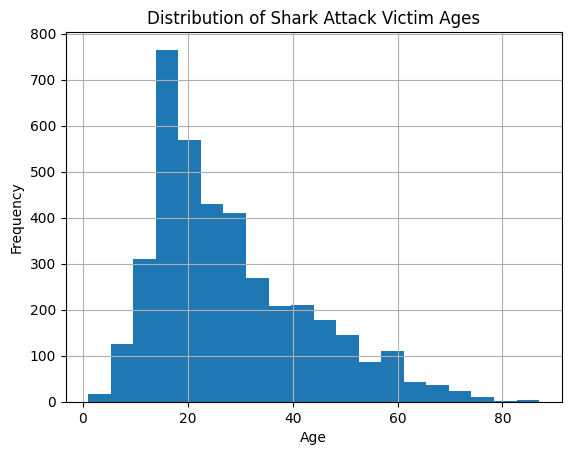

In [5]:
import pandas as pd

# Load dataset
shark = pd.read_excel('GSAF5.xls')

# ==============================================================================
# 1. DATA INSPECTION & UNNAMED COLUMN REMOVAL
# ==============================================================================
print("=== 1. Initial Data Inspection ===")
print(f"Original Dimensions: {shark.shape[0]} rows x {shark.shape[1]} columns")
print("Original Columns:\n", shark.columns.tolist(), "\n")

# Drop all unnamed columns
shark_clean = shark.drop(columns=shark.filter(like="Unnamed").columns).copy()

print(f"Cleaned Dimensions: {shark_clean.shape[0]} rows x {shark_clean.shape[1]} columns")
print("Cleaned Columns:\n", shark_clean.columns.tolist(), "\n")


# ==============================================================================
# 2. YEAR CLEANING, FULL RANGE, & TREND ANALYSIS
# ==============================================================================
print("=== 2. Year Analysis ===")

# Clean Year column into numeric float format
shark_clean['Year_clean'] = pd.to_numeric(shark_clean['Year'], errors='coerce')
shark_clean['Year_clean'] = shark_clean['Year_clean'].replace(0, pd.NA)

# Full dataset range (BEFORE filtering)
full_min_year = shark_clean['Year_clean'].min()
full_max_year = shark_clean['Year_clean'].max()

print("--- Full Dataset Year Range (Pre-Filter) ---")
print(f"Oldest Year in Dataset : {int(full_min_year)}")
print(f"Newest Year in Dataset : {int(full_max_year)}\n")

# Filter for years 1940 onwards
shark_1940 = shark_clean[shark_clean['Year_clean'] >= 1940]

# Calculate annual attack frequencies for 1940+
attacks_by_year = shark_1940['Year_clean'].value_counts().sort_index()

print("--- Filtered Trends (1940 - Present) ---")
print(f"Most Attacks in a Year  : {attacks_by_year.max()} (Year: {int(attacks_by_year.idxmax())})")
print(f"Least Attacks in a Year : {attacks_by_year.min()} (Year: {int(attacks_by_year.idxmin())})")
print(f"Average Attacks per Year: {attacks_by_year.mean():.4f}\n")

# Trend commentary
print(
    "Trend Observation: Attacks have generally increased over time since 1940, "
    "with a noticeable decline beginning around the mid-2010s.\n"
)


# ==============================================================================
# 3. AGE CLEANING & HISTOGRAM
# ==============================================================================
print("=== 3. Age Distribution ===")

# Clean Age column by coercing non-numeric values ('?', strings) to NaN
shark_clean['Age_clean'] = pd.to_numeric(shark_clean['Age'], errors='coerce')

# Plot histogram of valid ages
shark_clean['Age_clean'].plot(
    kind='hist',
    title='Distribution of Shark Attack Victim Ages',
    xlabel='Age',
    bins=20,
    grid=True
)
print("Histogram generated for cleaned numeric ages.\n")


# ==============================================================================
# 4. VICTIM SEX PROPORTION
# ==============================================================================
print("=== 4. Demographics (Male Victims) ===")

total_reports = len(shark_clean)

# Standardize text and search for 'M'
sex_series = shark_clean['Sex'].astype(str).str.strip().str.upper()
male_count = sex_series.str.startswith('M').sum()
male_proportion = male_count / total_reports

print(f"Total Reports  : {total_reports}")
print(f"Male Victims   : {male_count}")
print(f"Male Proportion: {male_proportion:.4f}\n")


# ==============================================================================
# 5. ATTACK TYPE CLEANING & PROPORTION
# ==============================================================================
print("=== 5. Attack Type Analysis ===")

# Standardize Type into three categories: Provoked, Unprovoked, or Unknown
shark_clean['Type_clean'] = shark_clean['Type'].astype(str).str.strip().str.capitalize()
shark_clean['Type_clean'] = shark_clean['Type_clean'].apply(
    lambda x: x if x in ["Provoked", "Unprovoked"] else "Unknown"
)

# Calculate proportion of Unprovoked attacks as a decimal
prop_unprovoked = (shark_clean['Type_clean'] == 'Unprovoked').mean()

print("Category Breakdown:")
print(shark_clean['Type_clean'].value_counts())
print(f"\nProportion of Unprovoked Attacks: {prop_unprovoked:.4f}")

### *Evaluation of AI suggestions




```
# This is formatted as code
```

| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | This change was for question 1.1. It made my code much more readable. I also liked how it made comparisions of the cleaning more visible to confirm that the cleaning worked. |
| 2 | Accept | This change was for question 1.2. I think the cross tabulation was much more concise and legible. It also provided more thorough explanations on the significance of the missing data and worded it better than I did. |
| 3 | Modify | The changes it provided were very neat and organized. The histogram was also much more detailed. However, I personally liked the proportions as decimals rather than it being in percentage. Also, the year data was wrong, as it specifies that the ranges should be calculated before the years are confined to those after 1940. |
| 4 | Accept | The above modifications were added to accurately reflect the assignment's requirements.


### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
#Question 1.1
import pandas as pd

# Load dataset
airbnb = pd.read_csv('airbnb_hw.csv')

# --- 1. Initial State Analysis ---
print("=== Initial Column State ===")
print("Data Type:", airbnb['Price'].dtype)
print(airbnb['Price'].describe())
print()

# Identify rows with commas using a single reusable boolean mask
has_comma_mask = airbnb['Price'].astype(str).str.contains(',', na=False)
comma_total = has_comma_mask.sum()

print(f"Rows containing commas (prices > $999): {comma_total}")
print("These values will coerce to NaN during numeric conversion unless commas are removed.")
print()

# Store comma-containing rows for comparison
with_commas = airbnb[has_comma_mask]
print("First 5 rows containing commas:")
print(with_commas[['Price']].head())
print()

# --- 2. Data Cleaning Function ---
def clean_currency_column(df, col_name):
    """
    Safely converts a currency string column into a numeric float column
    by removing commas and handling invalid entries.
    """
    cleaned_series = (
        df[col_name]
        .astype(str)
        .str.replace(',', '', regex=False)
    )
    return pd.to_numeric(cleaned_series, errors='coerce')

# Apply cleaning
airbnb['Price_clean'] = clean_currency_column(airbnb, 'Price')

# --- 3. Dynamic Verification ---
print("=== Dynamic Verification of Cleaned Rows ===")
if not with_commas.empty:
    # Dynamically select the first 3 indices that originally had commas
    sample_indices = with_commas.index[:3]
    print(airbnb.loc[sample_indices, ['Price', 'Price_clean']])
print()

# --- 4. Post-Cleaning Analysis ---
print("=== Post-Cleaning Summary ===")
print(airbnb[['Price', 'Price_clean']].describe())
print()
print("Missing values in cleaned column:", airbnb['Price_clean'].isna().sum())

In [ ]:
#Question 1.2
import pandas as pd

# Load dataset
police = pd.read_csv('mn_police_use_of_force.csv')

# --- 1. Missing Value Analysis ---
total_rows = len(police)
missing_count = police['subject_injury'].isna().sum()
missing_prop = police['subject_injury'].isna().mean()

print(f"Total rows in dataset: {total_rows}")
print(f"Non-null 'subject_injury' entries:\n{police['subject_injury'].describe()}\n")
print(f"Missing 'subject_injury' count: {missing_count}")
print(f"Proportion of missing values: {missing_prop:.2%}\n")
print(
    "Concern: Over half of the cases lack injury reports, making it difficult "
    "to verify actual injury rates during police interactions.\n"
)

# --- 2. Data Cleaning ---
# Assign cleaned column directly to the existing DataFrame
police['subject_injury_clean'] = police['subject_injury'].fillna('Unknown')

print(f"Null values remaining after cleaning: {police['subject_injury_clean'].isna().sum()}\n")

# --- 3. Cross-Tabulation & Analysis ---
print(
    "Analysis: Most 'Unknown' cases occur with less-lethal or contact force types "
    "(e.g., bodily force, chemical irritants, tasers) where immediate visual injury "
    "is harder to document compared to firearms or projectiles.\n"
)

# Raw Counts Crosstab with Margins
crosstab_counts = pd.crosstab(
    police['subject_injury_clean'],
    police['force_type'],
    margins=True
)
print("=== Cross-Tabulation (Counts) ===")
print(crosstab_counts)
print()

# Relative Proportions Crosstab (Column Percentages)
crosstab_props = pd.crosstab(
    police['subject_injury_clean'],
    police['force_type'],
    normalize='columns'
).applymap(lambda x: f"{x:.1%}")

print("=== Cross-Tabulation (Column Proportions) ===")
print(crosstab_props)

In [ ]:
#Question 2
import pandas as pd

# Load dataset
shark = pd.read_excel('GSAF5.xls')

# ==============================================================================
# 1. DATA INSPECTION & UNNAMED COLUMN REMOVAL
# ==============================================================================
print("=== 1. Initial Data Inspection ===")
print(f"Original Dimensions: {shark.shape[0]} rows x {shark.shape[1]} columns")
print("Original Columns:\n", shark.columns.tolist(), "\n")

# Drop all unnamed columns
shark_clean = shark.drop(columns=shark.filter(like="Unnamed").columns).copy()

print(f"Cleaned Dimensions: {shark_clean.shape[0]} rows x {shark_clean.shape[1]} columns")
print("Cleaned Columns:\n", shark_clean.columns.tolist(), "\n")


# ==============================================================================
# 2. YEAR CLEANING, FULL RANGE, & TREND ANALYSIS
# ==============================================================================
print("=== 2. Year Analysis ===")

# Clean Year column into numeric float format
shark_clean['Year_clean'] = pd.to_numeric(shark_clean['Year'], errors='coerce')
shark_clean['Year_clean'] = shark_clean['Year_clean'].replace(0, pd.NA)

# Full dataset range (BEFORE filtering)
full_min_year = shark_clean['Year_clean'].min()
full_max_year = shark_clean['Year_clean'].max()

print("--- Full Dataset Year Range (Pre-Filter) ---")
print(f"Oldest Year in Dataset : {int(full_min_year)}")
print(f"Newest Year in Dataset : {int(full_max_year)}\n")

# Filter for years 1940 onwards
shark_1940 = shark_clean[shark_clean['Year_clean'] >= 1940]

# Calculate annual attack frequencies for 1940+
attacks_by_year = shark_1940['Year_clean'].value_counts().sort_index()

print("--- Filtered Trends (1940 - Present) ---")
print(f"Most Attacks in a Year  : {attacks_by_year.max()} (Year: {int(attacks_by_year.idxmax())})")
print(f"Least Attacks in a Year : {attacks_by_year.min()} (Year: {int(attacks_by_year.idxmin())})")
print(f"Average Attacks per Year: {attacks_by_year.mean():.4f}\n")

# Trend commentary
print(
    "Trend Observation: Attacks have generally increased over time since 1940, "
    "with a noticeable decline beginning around the mid-2010s.\n"
)


# ==============================================================================
# 3. AGE CLEANING & HISTOGRAM
# ==============================================================================
print("=== 3. Age Distribution ===")

# Clean Age column by coercing non-numeric values ('?', strings) to NaN
shark_clean['Age_clean'] = pd.to_numeric(shark_clean['Age'], errors='coerce')

# Plot histogram of valid ages
shark_clean['Age_clean'].plot(
    kind='hist',
    title='Distribution of Shark Attack Victim Ages',
    xlabel='Age',
    bins=20,
    grid=True
)
print("Histogram generated for cleaned numeric ages.\n")


# ==============================================================================
# 4. VICTIM SEX PROPORTION
# ==============================================================================
print("=== 4. Demographics (Male Victims) ===")

total_reports = len(shark_clean)

# Standardize text and search for 'M'
sex_series = shark_clean['Sex'].astype(str).str.strip().str.upper()
male_count = sex_series.str.startswith('M').sum()
male_proportion = male_count / total_reports

print(f"Total Reports  : {total_reports}")
print(f"Male Victims   : {male_count}")
print(f"Male Proportion: {male_proportion:.4f}\n")


# ==============================================================================
# 5. ATTACK TYPE CLEANING & PROPORTION
# ==============================================================================
print("=== 5. Attack Type Analysis ===")

# Standardize Type into three categories: Provoked, Unprovoked, or Unknown
shark_clean['Type_clean'] = shark_clean['Type'].astype(str).str.strip().str.capitalize()
shark_clean['Type_clean'] = shark_clean['Type_clean'].apply(
    lambda x: x if x in ["Provoked", "Unprovoked"] else "Unknown"
)

# Calculate proportion of Unprovoked attacks as a decimal
prop_unprovoked = (shark_clean['Type_clean'] == 'Unprovoked').mean()

print("Category Breakdown:")
print(shark_clean['Type_clean'].value_counts())
print(f"\nProportion of Unprovoked Attacks: {prop_unprovoked:.4f}")

### *Reflection on AI assistance
In your own words without generative AI.

\[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

The main improvements that were shown with artificial intelligence usage was cleaner and more organized code. These assignments had a lot of requirements, so my thought process as I worked through the questions got jumbled. Also, my experience with Pandas and NumPy are limited, whereas AI has a lot more to work with. Therefore, AI is able to provide code that is a lot neater, uses functions that make code more concise and faster to run, and presents code in a more readable way. However, AI also has many downsides. It cannot reason like a human does; I feel like many of these questions needed multiple viewpoints and thought to work it out. I had to guide the AI to get the answers that I needed because the AI couldn't approach the prompt in that way initially. Furthermore, AI did make mistakes. The AI couldn't read the file until I edited it; the AI wrote all the proportions as percentages even though a proportion is a ratio of two numbers and therefore should be a decimal. AI overall is an incredible tool and contains massive amounts of programming knowledge that I could never contain. However, AI is nothing more than a tool and needs human guidance to reach the proper results.
